<a href="https://colab.research.google.com/github/angelaoica-dev/challenge-TelecomX-2/blob/main/TelecomX_2Latam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📚 Bibliotecas y librerias

In [ ]:
import pandas as pd
import json
import requests
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#🛠️ Preparación de los Datos

#### Extracción

In [ ]:
url = "https://raw.githubusercontent.com/angelaoica-dev/challenge-TelecomX/main/datos_tratados.csv"
df = pd.read_csv(url)
df.head()

,ID Cliente,Abandono,Género,Veterano,Casado,Dependientes Económicos,Antigüedad (meses),Servicio Telefónico,Factura Electrónica,Cargo Mensual,...,TV en Streaming: Sí,Películas en Streaming: No,Películas en Streaming: Sí,Contrato: Mes a Mes,Contrato: Un Año,Contrato: Dos Años,Método de Pago: Transferencia Bancaria,Método de Pago: Tarjeta de Crédito,Método de Pago: Cheque Electrónico,Método de Pago: Cheque Enviado por Correo
0,0002-ORFBO,0,1,0,1,1,9,1,1,65.6,...,1,1,0,0,1,0,0,0,0,1
1,0003-MKNFE,0,0,0,0,0,9,1,0,59.9,...,0,0,1,1,0,0,0,0,0,1
2,0004-TLHLJ,1,0,0,0,0,4,1,1,73.9,...,0,1,0,1,0,0,0,0,1,0
3,0011-IGKFF,1,0,1,1,0,13,1,1,98.0,...,1,0,1,1,0,0,0,0,1,0
4,0013-EXCHZ,1,1,1,1,0,3,1,1,83.9,...,1,1,0,1,0,0,0,0,0,1


#### Eliminación de Columnas Irrelevantes

In [ ]:
df = df.drop(columns=['ID Cliente'])
df

,Abandono,Género,Veterano,Casado,Dependientes Económicos,Antigüedad (meses),Servicio Telefónico,Factura Electrónica,Cargo Mensual,Cargo Total,...,TV en Streaming: Sí,Películas en Streaming: No,Películas en Streaming: Sí,Contrato: Mes a Mes,Contrato: Un Año,Contrato: Dos Años,Método de Pago: Transferencia Bancaria,Método de Pago: Tarjeta de Crédito,Método de Pago: Cheque Electrónico,Método de Pago: Cheque Enviado por Correo
0,0,1,0,1,1,9,1,1,65.60,593.30,...,1,1,0,0,1,0,0,0,0,1
1,0,0,0,0,0,9,1,0,59.90,542.40,...,0,0,1,1,0,0,0,0,0,1
2,1,0,0,0,0,4,1,1,73.90,280.85,...,0,1,0,1,0,0,0,0,1,0
3,1,0,1,1,0,13,1,1,98.00,1237.85,...,1,0,1,1,0,0,0,0,1,0
4,1,1,1,1,0,3,1,1,83.90,267.40,...,1,1,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,1,0,0,0,13,1,0,55.15,742.90,...,0,1,0,0,1,0,0,0,0,1
7039,1,0,0,1,0,22,1,1,85.10,1873.70,...,0,0,1,1,0,0,0,0,1,0
7040,0,0,0,0,0,2,1,1,50.30,92.75,...,0,1,0,1,0,0,0,0,0,1
7041,0,0,0,1,1,67,1,0,67.85,4627.65,...,0,0,1,0,0,1,0,0,0,1


In [ ]:
df.columns

Index(['Abandono', 'Género', 'Veterano', 'Casado', 'Dependientes Económicos',
       'Antigüedad (meses)', 'Servicio Telefónico', 'Factura Electrónica',
       'Cargo Mensual', 'Cargo Total', 'Cuentas Diarias',
       'Multilinea Telefónica: No', 'Multilinea Telefónica: Sí',
       'Internet: DSL', 'Internet: Fibra Óptica', 'Internet: No',
       'Seguridad en Linea: No', 'Seguridad en Linea: Sí',
       'Respaldo en Linea: No', 'Respaldo en Linea: Sí',
       'Protección de Dispositivo: No', 'Protección de Dispositivo: Sí',
       'Soporte Técnico: No', 'Soporte Técnico: Sí', 'TV en Streaming: No',
       'TV en Streaming: Sí', 'Películas en Streaming: No',
       'Películas en Streaming: Sí', 'Contrato: Mes a Mes', 'Contrato: Un Año',
       'Contrato: Dos Años', 'Método de Pago: Transferencia Bancaria',
       'Método de Pago: Tarjeta de Crédito',
       'Método de Pago: Cheque Electrónico',
       'Método de Pago: Cheque Enviado por Correo'],
      dtype='object')

#### Encoding

In [ ]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.head()

,Abandono,Género,Veterano,Casado,Dependientes Económicos,Antigüedad (meses),Servicio Telefónico,Factura Electrónica,Cargo Mensual,Cargo Total,...,TV en Streaming: Sí,Películas en Streaming: No,Películas en Streaming: Sí,Contrato: Mes a Mes,Contrato: Un Año,Contrato: Dos Años,Método de Pago: Transferencia Bancaria,Método de Pago: Tarjeta de Crédito,Método de Pago: Cheque Electrónico,Método de Pago: Cheque Enviado por Correo
0,0,1,0,1,1,9,1,1,65.6,593.30,...,1,1,0,0,1,0,0,0,0,1
1,0,0,0,0,0,9,1,0,59.9,542.40,...,0,0,1,1,0,0,0,0,0,1
2,1,0,0,0,0,4,1,1,73.9,280.85,...,0,1,0,1,0,0,0,0,1,0
3,1,0,1,1,0,13,1,1,98.0,1237.85,...,1,0,1,1,0,0,0,0,1,0
4,1,1,1,1,0,3,1,1,83.9,267.40,...,1,1,0,1,0,0,0,0,0,1


In [ ]:
df['Abandono'].value_counts()

,count
Abandono,
0,5174
1,1869


#### Verificación de la Proporción de Cancelación (Churn)

In [ ]:
df['Abandono'].value_counts(normalize=True)

,proportion
Abandono,
0,0.73463
1,0.26537


In [ ]:
(df['Abandono'].value_counts(normalize=True) * 100).round(2)

,proportion
Abandono,
0,73.46
1,26.54


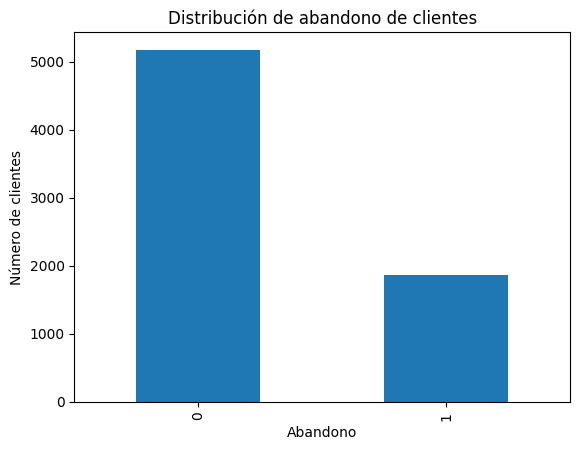

In [ ]:
df['Abandono'].value_counts().plot(kind='bar')

plt.title("Distribución de abandono de clientes")
plt.xlabel("Abandono")
plt.ylabel("Número de clientes")

plt.show()

Análisis de balance de clases

Se analizó la distribución de la variable objetivo **Abandono**, con el fin de identificar posibles desbalances entre las clases.

Los resultados muestran que aproximadamente el **73% de los clientes permanecen activos**, mientras que alrededor del **27% cancelan el servicio**.

Este desbalance es moderado y debe considerarse durante el entrenamiento de los modelos predictivos, ya que podría influir en la capacidad del modelo para identificar correctamente a los clientes que cancelan.

#### Balanceo de clases

In [ ]:
X = df.drop(columns=['Abandono'])
y = df['Abandono']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [ ]:
import pandas as pd

pd.Series(y_train_bal).value_counts()

,count
Abandono,
0,3622
1,3622


In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)

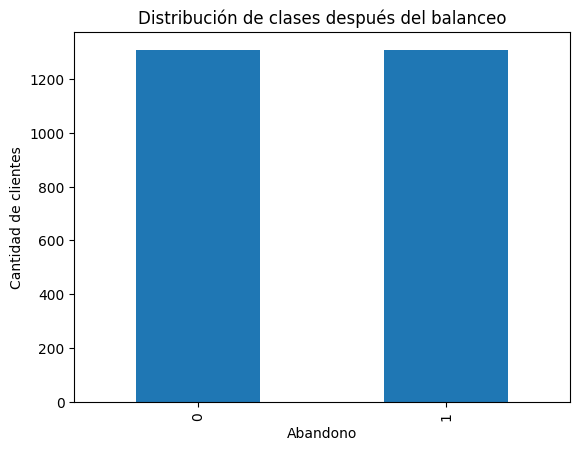

In [ ]:
pd.Series(y_train_bal).value_counts().plot(kind="bar")

plt.title("Distribución de clases después del balanceo")
plt.xlabel("Abandono")
plt.ylabel("Cantidad de clientes")
plt.show()

El análisis de la variable objetivo mostró un desbalance entre clientes que cancelaron el servicio y aquellos que permanecieron activos.

Para mejorar el desempeño de los modelos predictivos se aplicó la técnica **SMOTE (Synthetic Minority Oversampling Technique)**, la cual genera ejemplos sintéticos de la clase minoritaria.

El balanceo se realizó únicamente sobre el conjunto de entrenamiento para evitar filtraciones de información hacia el conjunto de prueba.

Este proceso permite que los modelos aprendan de forma más equilibrada los patrones asociados a la cancelación del servicio.

#### Normalización o Estandarización

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)

In [ ]:
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [ ]:
X_train_scaled.describe()

,Género,Veterano,Casado,Dependientes Económicos,Antigüedad (meses),Servicio Telefónico,Factura Electrónica,Cargo Mensual,Cargo Total,Cuentas Diarias,...,TV en Streaming: Sí,Películas en Streaming: No,Películas en Streaming: Sí,Contrato: Mes a Mes,Contrato: Un Año,Contrato: Dos Años,Método de Pago: Transferencia Bancaria,Método de Pago: Tarjeta de Crédito,Método de Pago: Cheque Electrónico,Método de Pago: Cheque Enviado por Correo
count,4.930000e+03,4.930000e+03,4.930000e+03,4.930000e+03,4.930000e+03,4.930000e+03,4.930000e+03,4.930000e+03,4.930000e+03,4.930000e+03,...,4.930000e+03,4.930000e+03,4.930000e+03,4.930000e+03,4.930000e+03,4.930000e+03,4.930000e+03,4.930000e+03,4.930000e+03,4.930000e+03
mean,3.459032e-17,1.405232e-17,-3.242842e-17,1.383613e-16,-8.935832e-17,-6.197432e-17,4.071568e-17,-1.697087e-16,2.334846e-16,2.158292e-16,...,1.080947e-17,5.188547e-17,-5.188547e-17,-3.819347e-17,4.395853e-17,-8.647579e-17,3.531095e-17,2.306021e-17,-9.079958e-17,4.179663e-17
std,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00,...,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00,1.000101e+00
min,-9.803154e-01,-4.378182e-01,-9.621753e-01,-6.593997e-01,-1.322612e+00,-3.174689e+00,-1.224745e+00,-1.550105e+00,-1.009596e+00,-1.550105e+00,...,-7.928904e-01,-1.249948e+00,-8.000333e-01,-1.097198e+00,-5.192657e-01,-5.640761e-01,-5.362298e-01,-5.277565e-01,-7.060313e-01,-5.406176e-01
25%,-9.803154e-01,-4.378182e-01,-9.621753e-01,-6.593997e-01,-9.566470e-01,3.149915e-01,-1.224745e+00,-9.560902e-01,-8.340343e-01,-9.560902e-01,...,-7.928904e-01,-1.249948e+00,-8.000333e-01,-1.097198e+00,-5.192657e-01,-5.640761e-01,-5.362298e-01,-5.277565e-01,-7.060313e-01,-5.406176e-01
50%,-9.803154e-01,-4.378182e-01,-9.621753e-01,-6.593997e-01,-1.433919e-01,3.149915e-01,8.164966e-01,1.813322e-01,-3.915193e-01,1.813322e-01,...,-7.928904e-01,8.000333e-01,-8.000333e-01,9.114122e-01,-5.192657e-01,-5.640761e-01,-5.362298e-01,-5.277565e-01,-7.060313e-01,-5.406176e-01
75%,1.020080e+00,-4.378182e-01,1.039312e+00,1.516531e+00,9.545025e-01,3.149915e-01,8.164966e-01,8.276137e-01,6.775410e-01,8.276137e-01,...,1.261208e+00,8.000333e-01,1.249948e+00,9.114122e-01,-5.192657e-01,-5.640761e-01,-5.362298e-01,-5.277565e-01,1.416368e+00,-5.406176e-01
max,1.020080e+00,2.284053e+00,1.039312e+00,1.516531e+00,1.605107e+00,3.149915e-01,8.164966e-01,1.780029e+00,2.791274e+00,1.780029e+00,...,1.261208e+00,8.000333e-01,1.249948e+00,9.114122e-01,1.925796e+00,1.772811e+00,1.864872e+00,1.894813e+00,1.416368e+00,1.849736e+00


Normalización y Estandarización de los Datos

Antes de entrenar los modelos predictivos se evaluó la necesidad de escalar las variables numéricas. Algunos algoritmos de Machine Learning, especialmente aquellos basados en distancia como **Regresión Logística, KNN y SVM**, son sensibles a la escala de los datos.

Para garantizar que todas las variables contribuyan de manera equilibrada al modelo, se aplicó **estandarización mediante StandardScaler**, transformando los datos para que tengan media cercana a 0 y desviación estándar cercana a 1.

Es importante destacar que este proceso se aplicó únicamente a los modelos que lo requieren, ya que algoritmos basados en árboles como **Decision Tree o Random Forest** no son sensibles a la escala de los datos.

#🎯 Correlación y Selección de Variables

#### Análisis de correlación

In [ ]:
correlacion = df.corr()
correlacion

,Abandono,Género,Veterano,Casado,Dependientes Económicos,Antigüedad (meses),Servicio Telefónico,Factura Electrónica,Cargo Mensual,Cargo Total,...,TV en Streaming: Sí,Películas en Streaming: No,Películas en Streaming: Sí,Contrato: Mes a Mes,Contrato: Un Año,Contrato: Dos Años,Método de Pago: Transferencia Bancaria,Método de Pago: Tarjeta de Crédito,Método de Pago: Cheque Electrónico,Método de Pago: Cheque Enviado por Correo
Abandono,1.000000,0.008612,0.150889,-0.150448,-0.164221,-0.352229,0.011942,0.191825,0.193356,-0.198324,...,0.063228,-0.061382,0.061382,0.405103,-0.177820,-0.302253,-0.117937,-0.134302,0.301919,-0.091683
Género,0.008612,1.000000,0.001874,0.001808,-0.010517,-0.005106,0.006488,0.011754,0.014569,0.000080,...,0.008393,-0.010487,0.010487,0.003386,-0.008026,0.003695,0.016024,-0.001215,-0.000752,-0.013744
Veterano,0.150889,0.001874,1.000000,0.016479,-0.211185,0.016567,0.008576,0.156530,0.220173,0.103006,...,0.105378,-0.120176,0.120176,0.138360,-0.046262,-0.117000,-0.016159,-0.024135,0.171718,-0.153477
Casado,-0.150448,0.001808,0.016479,1.000000,0.452676,0.379697,0.017706,-0.014877,0.096848,0.317504,...,0.124666,-0.117412,0.117412,-0.280865,0.082783,0.248091,0.110706,0.082029,-0.083852,-0.095125
Dependientes Económicos,-0.164221,-0.010517,-0.211185,0.452676,1.000000,0.159712,-0.001762,-0.111377,-0.113890,0.062078,...,-0.016558,0.039741,-0.039741,-0.231720,0.068368,0.204613,0.052021,0.060267,-0.150642,0.059071
Antigüedad (meses),-0.352229,-0.005106,0.016567,0.379697,0.159712,1.000000,0.008448,0.006152,0.247900,0.826178,...,0.279756,-0.286111,0.286111,-0.645561,0.202570,0.558533,0.243510,0.233006,-0.208363,-0.233852
Servicio Telefónico,0.011942,0.006488,0.008576,0.017706,-0.001762,0.008448,1.000000,0.016505,0.247398,0.113214,...,-0.022574,0.032959,-0.032959,-0.000742,-0.002791,0.003519,0.007556,-0.007721,0.003062,-0.003319
Factura Electrónica,0.191825,0.011754,0.156530,-0.014877,-0.111377,0.006152,0.016505,1.000000,0.352150,0.158574,...,0.223841,-0.211716,0.211716,0.169096,-0.051391,-0.147889,-0.016332,-0.013589,0.208865,-0.205398
Cargo Mensual,0.193356,0.014569,0.220173,0.096848,-0.113890,0.247900,0.247398,0.352150,1.000000,0.651174,...,0.629603,-0.627429,0.627429,0.060165,0.004904,-0.074681,0.042812,0.030550,0.271625,-0.377437
Cargo Total,-0.198324,0.000080,0.103006,0.317504,0.062078,0.826178,0.113214,0.158574,0.651174,1.000000,...,0.514973,-0.520122,0.520122,-0.444255,0.170814,0.354481,0.185987,0.182915,-0.059246,-0.295758


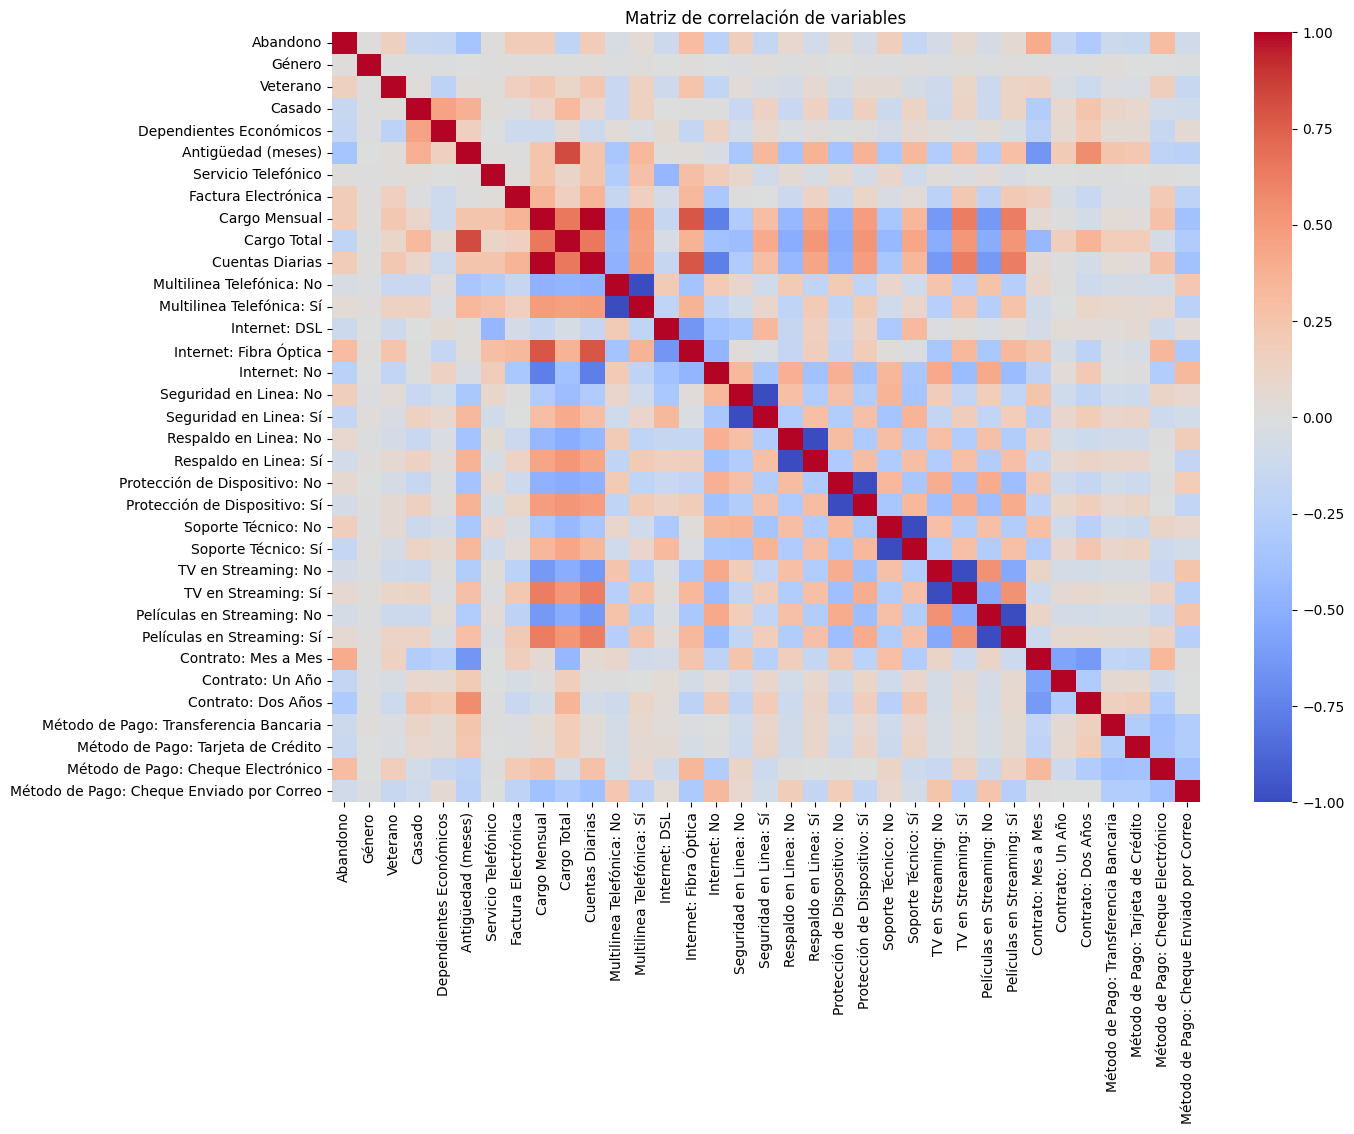

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Matriz de correlación de variables")
plt.show()

In [ ]:
df.corr()['Abandono'].sort_values(ascending=False)

,Abandono
Abandono,1.000000
Contrato: Mes a Mes,0.405103
Internet: Fibra Óptica,0.308020
Método de Pago: Cheque Electrónico,0.301919
Cargo Mensual,0.193356
Cuentas Diarias,0.193356
Factura Electrónica,0.191825
Seguridad en Linea: No,0.171226
Soporte Técnico: No,0.164674
Veterano,0.150889


<Figure size 600x800 with 0 Axes>

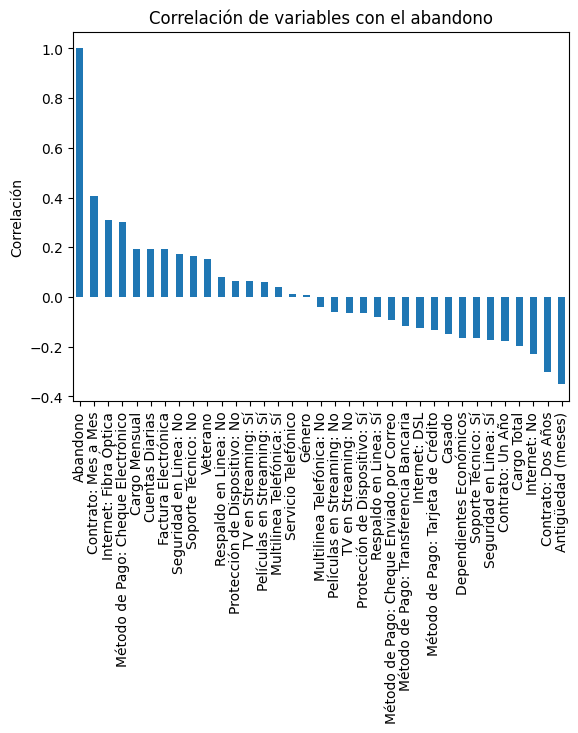

In [ ]:
plt.figure(figsize=(6,8))

df.corr()[['Abandono']].sort_values(by='Abandono', ascending=False).plot(
    kind='bar',
    legend=False
)

plt.title("Correlación de variables con el abandono")
plt.ylabel("Correlación")
plt.show()

Análisis de Correlación

Se calculó la matriz de correlación entre las variables numéricas con el objetivo de identificar relaciones entre ellas y detectar cuáles presentan mayor asociación con la variable objetivo **Abandono (Churn)**.

La visualización mediante un mapa de calor permitió identificar patrones de correlación positiva y negativa entre las variables.

Se observó que algunas variables, como los **cargos mensuales** y ciertos **tipos de servicio de internet**, presentan correlaciones positivas con la cancelación, lo que indica que podrían aumentar la probabilidad de abandono.

Por otro lado, variables como **tenure (tiempo como cliente)** y **contratos de mayor duración** presentan correlaciones negativas con el churn, lo que sugiere que los clientes con mayor antigüedad o contratos más largos tienden a permanecer en el servicio.

Estas variables se consideran importantes candidatas para los modelos predictivos de cancelación.

#### Análisis Dirigido

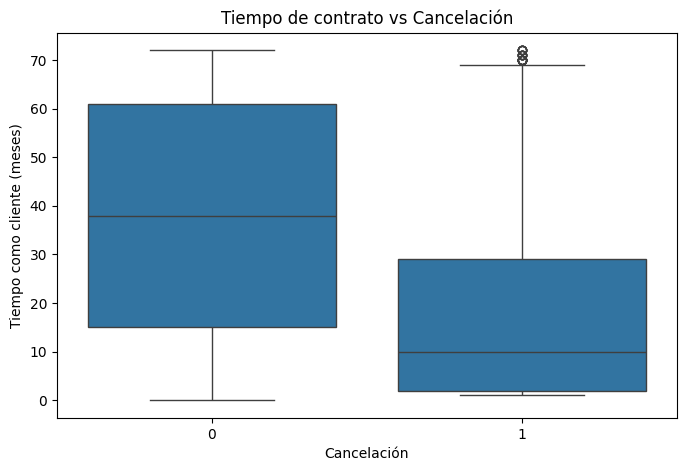

In [37]:
#Tiempo de contrato (tenure) vs Cancelación
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Abandono',
    y='Antigüedad (meses)',
    data=df
)

plt.title('Tiempo de contrato vs Cancelación')
plt.xlabel('Cancelación')
plt.ylabel('Tiempo como cliente (meses)')

plt.show()

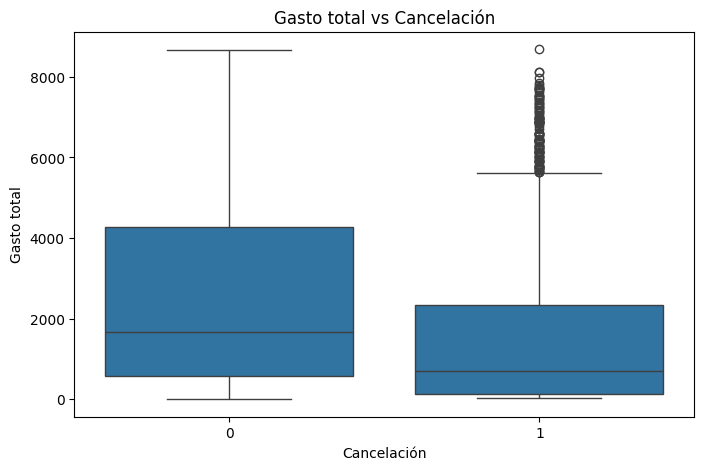

In [38]:
#Gasto total vs Cancelación
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Abandono',
    y='Cargo Total',
    data=df
)

plt.title('Gasto total vs Cancelación')
plt.xlabel('Cancelación')
plt.ylabel('Gasto total')

plt.show()

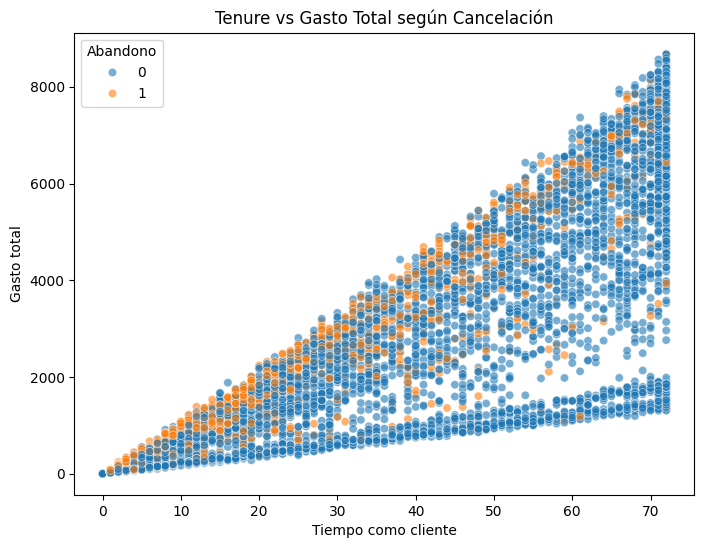

In [39]:
#Scatter plot (relación entre variables)
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Antigüedad (meses)',
    y='Cargo Total',
    hue='Abandono',
    alpha=0.6
)

plt.title('Tenure vs Gasto Total según Cancelación')
plt.xlabel('Tiempo como cliente')
plt.ylabel('Gasto total')

plt.show()

**Relación entre variables numéricas y cancelación**

Se analizó cómo ciertas variables numéricas se relacionan con la cancelación del servicio.


**Tiempo de contrato vs cancelación**

El análisis mediante boxplots mostró que los clientes que cancelan el servicio tienden a tener menor tiempo de permanencia en la empresa. Esto sugiere que el riesgo de cancelación es mayor durante los primeros meses del servicio.


**Gasto total vs cancelación**

Se observó que los clientes con mayor gasto acumulado tienden a permanecer más tiempo en la compañía, mientras que aquellos con menor gasto total presentan mayores tasas de cancelación.

**Relación entre tiempo de cliente y gasto total**

El gráfico de dispersión mostró una relación positiva entre el tiempo como cliente y el gasto total. Los clientes con mayor antigüedad tienden a acumular mayor gasto y presentan menor probabilidad de cancelar el servicio.

Estos patrones sugieren que la antigüedad del cliente y el gasto acumulado son variables relevantes para la predicción de cancelación.